In [131]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [132]:
df=pd.read_csv('creditcard_2023.csv')

In [133]:
df.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


In [134]:
df['Class'].value_counts()
# class balance

Class
0    284315
1    284315
Name: count, dtype: int64

In [135]:
df.shape

(568630, 31)

In [136]:
# EDA
df.isnull().sum()

# No null preset
# from V1 to V28 it represent the transaction amount,time,error etc (mention on the dataset discription)

id        0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [137]:
df.info()
# No null and all are in numaric form so no need of object encoding

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568630 entries, 0 to 568629
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      568630 non-null  int64  
 1   V1      568630 non-null  float64
 2   V2      568630 non-null  float64
 3   V3      568630 non-null  float64
 4   V4      568630 non-null  float64
 5   V5      568630 non-null  float64
 6   V6      568630 non-null  float64
 7   V7      568630 non-null  float64
 8   V8      568630 non-null  float64
 9   V9      568630 non-null  float64
 10  V10     568630 non-null  float64
 11  V11     568630 non-null  float64
 12  V12     568630 non-null  float64
 13  V13     568630 non-null  float64
 14  V14     568630 non-null  float64
 15  V15     568630 non-null  float64
 16  V16     568630 non-null  float64
 17  V17     568630 non-null  float64
 18  V18     568630 non-null  float64
 19  V19     568630 non-null  float64
 20  V20     568630 non-null  float64
 21  V21     56

In [138]:
# check the stats 
df.describe()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,568630.000000,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,...,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,568630.000000,568630.0
mean,284314.500000,-5.638058e-17,-1.319545e-16,-3.518788e-17,-2.879008e-17,7.997245e-18,-3.958636e-17,-3.198898e-17,2.109273e-17,3.998623e-17,...,4.758361e-17,3.948640e-18,6.194741e-18,-2.799036e-18,-3.178905e-17,-7.497417e-18,-3.598760e-17,2.609101e-17,12041.957635,0.5
std,164149.486122,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,...,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,6919.644449,0.5
min,0.000000,-3.495584e+00,-4.996657e+01,-3.183760e+00,-4.951222e+00,-9.952786e+00,-2.111111e+01,-4.351839e+00,-1.075634e+01,-3.751919e+00,...,-1.938252e+01,-7.734798e+00,-3.029545e+01,-4.067968e+00,-1.361263e+01,-8.226969e+00,-1.049863e+01,-3.903524e+01,50.010000,0.0
25%,142157.250000,-5.652859e-01,-4.866777e-01,-6.492987e-01,-6.560203e-01,-2.934955e-01,-4.458712e-01,-2.835329e-01,-1.922572e-01,-5.687446e-01,...,-1.664408e-01,-4.904892e-01,-2.376289e-01,-6.515801e-01,-5.541485e-01,-6.318948e-01,-3.049607e-01,-2.318783e-01,6054.892500,0.0
50%,284314.500000,-9.363846e-02,-1.358939e-01,3.528579e-04,-7.376152e-02,8.108788e-02,7.871758e-02,2.333659e-01,-1.145242e-01,9.252647e-02,...,-3.743065e-02,-2.732881e-02,-5.968903e-02,1.590123e-02,-8.193162e-03,-1.189208e-02,-1.729111e-01,-1.392973e-02,12030.150000,0.5
75%,426471.750000,8.326582e-01,3.435552e-01,6.285380e-01,7.070047e-01,4.397368e-01,4.977881e-01,5.259548e-01,4.729905e-02,5.592621e-01,...,1.479787e-01,4.638817e-01,1.557153e-01,7.007374e-01,5.500147e-01,6.728879e-01,3.340230e-01,4.095903e-01,18036.330000,1.0
max,568629.000000,2.229046e+00,4.361865e+00,1.412583e+01,3.201536e+00,4.271689e+01,2.616840e+01,2.178730e+02,5.958040e+00,2.027006e+01,...,8.087080e+00,1.263251e+01,3.170763e+01,1.296564e+01,1.462151e+01,5.623285e+00,1.132311e+02,7.725594e+01,24039.930000,1.0


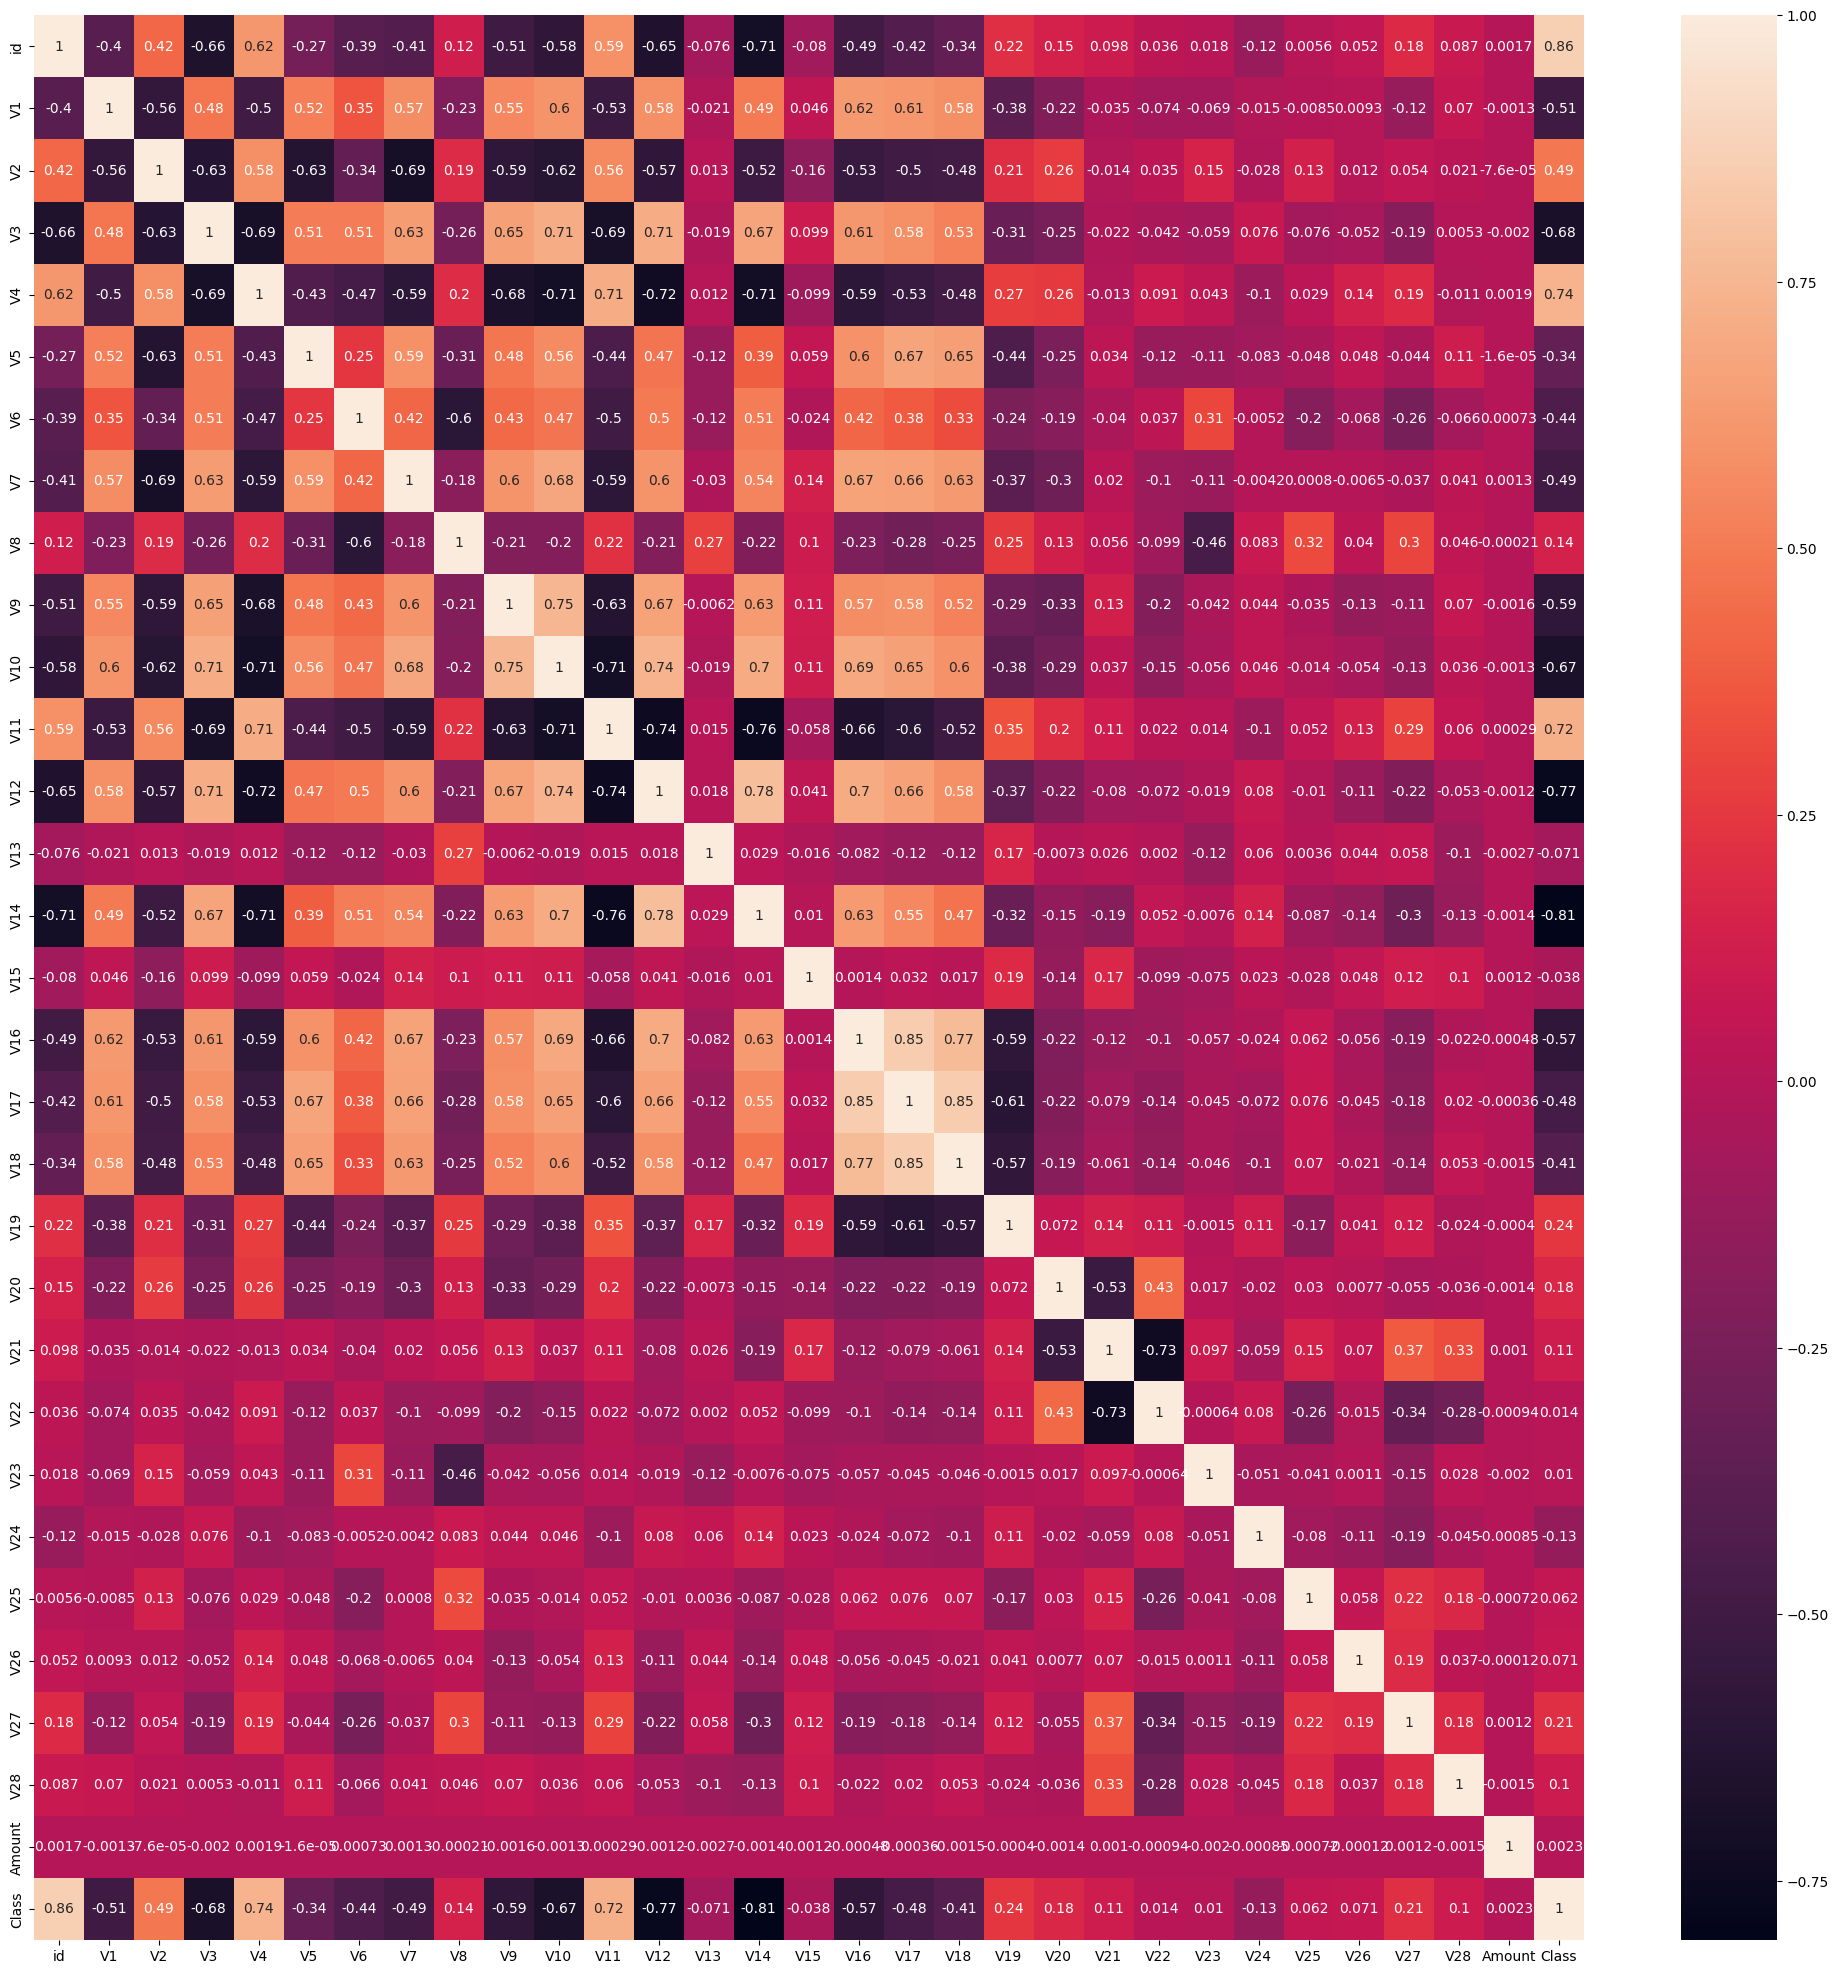

In [139]:
plt.figure(figsize=(25, 25))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [141]:
feature=df.drop(columns=['Class','id'])
target=df['Class']

In [142]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
feature.iloc[:]=ss.fit_transform(feature.iloc[:])

In [143]:
feature.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,0.637735,...,0.091202,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,0.858447
1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,0.529808,...,-0.233984,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,-0.796369
2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,0.690708,...,0.361652,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,-1.377011
3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,0.575231,...,-0.378223,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,-0.962119
4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,0.968046,...,0.247237,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,0.323285


In [146]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(feature,target,train_size=0.20)

In [147]:
print(xtrain.shape,ytrain.shape)
print(xtest.shape,ytest.shape)

(113726, 29) (113726,)
(454904, 29) (454904,)


In [148]:
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [149]:
def mymodel(model):
    model.fit(xtrain, ytrain)
    ypred = model.predict(xtest)
    # evaluation metrics
    c = pd.DataFrame(confusion_matrix(ytest, ypred),
                     index = ['Low','High'],
                     columns = ['Low','High'])
    print(f'Confusion Matrix : \n{c}')
    print(f'Classification Report : \n{classification_report(ytest, ypred)}')
    return model

In [150]:
lm=mymodel(LogisticRegression())
lm

Confusion Matrix : 
         Low    High
Low   222703    4812
High   11095  216294
Classification Report : 
              precision    recall  f1-score   support

           0       0.95      0.98      0.97    227515
           1       0.98      0.95      0.96    227389

    accuracy                           0.97    454904
   macro avg       0.97      0.97      0.97    454904
weighted avg       0.97      0.97      0.97    454904



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [151]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout

In [152]:
model = Sequential([
    Dense(128,activation='relu',input_shape=(xtrain.shape[1],)),
    Dense(64,activation='relu'),
    Dense(16,activation='relu'),
    Dense(1,activation='sigmoid')
])

In [153]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [154]:
# train the mdoel
model.fit(xtrain,ytrain,epochs=25,batch_size=100,validation_split=0.20)

Epoch 1/25
910/910 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9726 - loss: 0.0743 - val_accuracy: 0.9907 - val_loss: 0.0262
Epoch 2/25
910/910 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9947 - loss: 0.0173 - val_accuracy: 0.9968 - val_loss: 0.0112
Epoch 3/25
910/910 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9976 - loss: 0.0087 - val_accuracy: 0.9975 - val_loss: 0.0090
Epoch 4/25
910/910 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9983 - loss: 0.0068 - val_accuracy: 0.9981 - val_loss: 0.0077
Epoch 5/25
910/910 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9985 - loss: 0.0058 - val_accuracy: 0.9973 - val_loss: 0.0095
Epoch 6/25
910/910 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9987 - loss: 0.0048 - val_accuracy: 0.9980 - val_loss: 0.0078
Epoch 7/25
910/910 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9989 - loss: 0.0039 - val_accuracy: 0.9977 - val_loss: 0.0078
Epoch 8/25
910/910 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9989 - loss: 0.0037 - val_accuracy: 0.

In [155]:
loss,accuracy=model.evaluate(xtest,ytest)
print(f'test loss {loss}')
print(f'test accuracy {accuracy}')

14216/14216 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.9989 - loss: 0.0056
test loss 0.005589163862168789
test accuracy 0.9989228248596191


In [156]:
ypred_prob=model.predict(xtest)

14216/14216 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step


In [157]:
ypred=(ypred_prob >0.5).astype(int)

In [158]:
from sklearn.metrics import classification_report,confusion_matrix

In [159]:
print(confusion_matrix(ytest,ypred))
print(classification_report(ytest,ypred))

[[227045    470]
 [    20 227369]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227515
           1       1.00      1.00      1.00    227389

    accuracy                           1.00    454904
   macro avg       1.00      1.00      1.00    454904
weighted avg       1.00      1.00      1.00    454904

